# Recognizing Clothing with a CNN (Fashion-MNIST)

Welcome! By the end of this notebook, you'll have built a small **artificial brain** that can
look at a picture of a clothing item and tell you which of 10 kinds it is (shirt, sneaker, bag, …).

Just run each cell in order (click it and press **Shift + Enter**), read the explanations, and
watch what happens.

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h1 style="margin-top:0;"> التعرّف على الملابس بشبكة CNN (Fashion-MNIST)</h1>
<p>مرحبًا بك! في نهاية هذا التطبيق العملي ستكون قد بنيت <strong>دماغًا اصطناعيًا</strong> صغيرًا قادرًا على النظر إلى صورة قطعة ملابس وإخبارك بأيٍّ من 10 أصناف هي (قميص، حذاء رياضي، حقيبة، …).</p>
<p>فقط شغّل كل خلية بالترتيب (انقر عليها واضغط <strong>Shift + Enter</strong>)، واقرأ الشرح، وراقب ما يحدث.</p>
</div>

## Step 1 — Get our tools

**PyTorch** is a free library that does all the heavy math for us. We also grab **matplotlib**,
which lets us draw pictures so we can actually *see* the clothes.

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h2 style="margin-top:0;">الخطوة 1 — نجهّز أدواتنا</h2>
<p><strong>بايتورش (PyTorch)</strong> مكتبة مجانية تقوم بكل العمليات الحسابية الثقيلة نيابةً عنّا. كما نستعين بمكتبة <strong>matplotlib</strong> التي تتيح لنا رسم الصور حتى نتمكّن فعليًا من <em>رؤية</em> الملابس.</p>
</div>

In [13]:
# نجهّز الأدوات التي سنستخدمها
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

## Step 2 — the Fashion-MNIST dataset

**Fashion-MNIST** is a famous free collection of **70,000 tiny grayscale photos of clothing**
in 10 categories (T-shirt, trouser, pullover, dress, coat, sandal, shirt, sneaker, bag, ankle boot),
each labeled with the correct category. Each picture is **28 × 28 pixels** — a drop-in replacement
for MNIST, but a bit harder.

We split them into two piles:
- **Training set (60,000)** — the flashcards our brain practices on.
- **Test set (10,000)** — images it has *never seen*, to check if it truly learned.

`ToTensor()` just turns each picture into numbers the computer can do math with.

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h2 style="margin-top:0;">الخطوة 2 — نجلب بيانات Fashion-MNIST </h2>
<p><strong>Fashion-MNIST</strong> مجموعة مجانية شهيرة تحوي <strong>70,000 صورة رماديّة صغيرة لقطع ملابس</strong> ضمن 10 فئات (قميص، بنطال، كنزة، فستان، معطف، صندل، قميص رسمي، حذاء رياضي، حقيبة، حذاء برقبة)، كل صورة مصحوبة بفئتها الصحيحة، وحجم كل صورة <strong>28 × 28 بكسل</strong> — بديلٌ مطابقٌ لـ MNIST لكنّه أصعب قليلًا.</p>
<p>نقسمها إلى كومتين:</p>
<ul style="padding-right:22px; margin:0;">
<li style="margin-bottom:6px;"><strong>مجموعة التدريب (60,000):</strong> البطاقات التي يتمرّن عليها دماغنا.</li>
<li style="margin-bottom:6px;"><strong>مجموعة الاختبار (10,000):</strong> صور <em>لم يرها الدماغ من قبل</em>، للتأكد من أنه تعلّم فعلًا.</li>
</ul>
<p style="margin-top:10px; margin-bottom:0;">الأمر <code>ToTensor()</code> يحوّل كل صورة إلى أرقام يستطيع الحاسوب إجراء العمليات عليها.</p>
</div>

In [14]:
# نحمّل الصور ونجهّزها في دفعات صغيرة (batches)
transform = transforms.ToTensor()   # picture -> numbers / صورة إلى أرقام

train_dataset = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# A "loader" hands the images to the network in small groups (batches).
train_loader = DataLoader(train_dataset, batch_size=64,   shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1000, shuffle=False)

print("Training images / صور التدريب:", len(train_dataset))
print("Test images / صور الاختبار:   ", len(test_dataset))

Training images / صور التدريب: 60000
Test images / صور الاختبار:    10000


### Let's look at some Pictures

Run this cell — you should see 10 little clothing photos with their correct labels.

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h3 style="margin-top:0;">لنلقِ نظرة على بعض الصور</h3>
<p style="margin-bottom:0;">شغّل هذه الخلية — من المفترض أن ترى 10 صور صغيرة لقطع ملابس مع إجاباتها الصحيحة.</p>
</div>

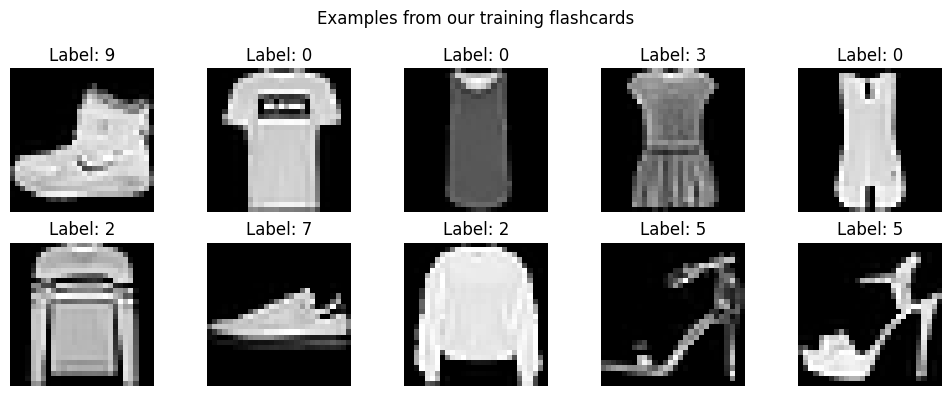

In [15]:
# نعرض 10 صور مع إجاباتها الصحيحة
plt.figure(figsize=(10, 4))
for i in range(10):
    image, label = train_dataset[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(image[0], cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
plt.suptitle("Examples from our training flashcards")
plt.tight_layout()
plt.show()

## Step 3 — Build the "brain" (a CNN)

This time the brain is a **Convolutional Neural Network (CNN)** — a kind built specially for images.
Instead of flattening the picture into a line right away (which throws away *where* things are), a CNN
keeps the 2D picture and scans it with small sliding windows.

- **Conv (convolution) layer** — slides a tiny window (a "filter") over the image to spot a simple
  pattern: an edge, a corner, a texture. Each filter makes a "feature map." Our first conv makes 32
  maps, the second makes 64 — and it keeps the 2D shape, so it knows *where* each pattern is.
- **ReLU** — the same on/off rule as before (negative → 0), applied after each conv.
- **MaxPool** — shrinks the image by half, keeping the strongest signal in each little 2×2 patch.
  After two pools: `28×28 → 14×14 → 7×7`.
- **Flatten + two Linear layers** — *now* we unroll what's left (`64 × 7 × 7`) into a line and turn it
  into **10 final scores**, one per category (0–9). The highest score is the guess.

A CNN usually beats the plain network on images because it understands **shapes and where they are**,
not just isolated pixels.

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h2 style="margin-top:0;">الخطوة 3 — نبني «الدماغ» (شبكة التفافية CNN)</h2>
<p>هذه المرّة الدماغ <strong>شبكة عصبية التفافية (CNN)</strong> — نوعٌ مصمَّمٌ خصيصًا للصور. فبدل فرد الصورة إلى خطٍّ فورًا (ممّا يُضيّع «مكان» الأشياء)، تحتفظ الـ CNN بالصورة ثنائية الأبعاد وتمسحها بنوافذ صغيرة متحرّكة.</p>
<ul style="padding-right:22px; margin:0;">
<li style="margin-bottom:8px;"><strong>طبقة الالتفاف (Conv):</strong> تُمرّر نافذةً صغيرة («مرشِّح») على الصورة لالتقاط نمطٍ بسيط: حافة، زاوية، ملمس. كل مرشِّح يُنتج «خريطة سمات». أوّل طبقة تُنتج 32 خريطة والثانية 64 — وتحافظ على الشكل ثنائي الأبعاد فتعرف «أين» يقع كل نمط.</li>
<li style="margin-bottom:8px;"><strong>ReLU:</strong> نفس قاعدة التشغيل/الإيقاف (السالب ← صفر)، تُطبَّق بعد كل التفاف.</li>
<li style="margin-bottom:8px;"><strong>التجميع الأقصى (MaxPool):</strong> يُصغّر الصورة إلى النصف مع إبقاء أقوى إشارة في كل مربّع 2×2. بعد تجميعين: <code>28×28 ← 14×14 ← 7×7</code>.</li>
<li style="margin-bottom:0;"><strong>Flatten وطبقتان خطّيتان:</strong> الآن نفرد ما تبقّى (<code>64 × 7 × 7</code>) إلى خطٍّ ونحوّله إلى <strong>10 درجات نهائية</strong>، واحدة لكل فئة (0 حتى 9). الأعلى هو التخمين.</li>
</ul>
<p style="margin-bottom:0;">تتفوّق الـ CNN عادةً على الشبكة البسيطة في الصور لأنّها تفهم <strong>الأشكال ومواضعها</strong>، لا البكسلات المنعزلة فقط.</p>
</div>

In [16]:
# تعريف بنية الشبكة (شبكة التفافية CNN)
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),   # 1 -> 32 feature maps (keeps 28x28)
    nn.ReLU(),                                    # the on/off gate / البوابة
    nn.MaxPool2d(2),                              # halves the image: 28 -> 14

    nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 32 -> 64 feature maps
    nn.ReLU(),                                    # conv -> ReLU -> shrink : 14x14 -> 7x7
    nn.MaxPool2d(2),                              # halves the image: 14 -> 7

    nn.Flatten(),                                 # 2D feature maps -> one line (unroll what's left)
    nn.Linear(64 * 7 * 7, 128),                   # 64 maps of 7x7 -> 128
    nn.ReLU(),                                    # first linear + ReLU
    nn.Linear(128, 10),                           # -> 10 scores
)

## Step 4 — Set up the learning rules

Right now our brain is empty and guesses randomly. To help it improve we need two things:

- **The "grader" (loss)** — measures **how wrong** each guess was, as one number. **Big = very
  wrong, small = doing great.** Our goal is to make it as small as possible.
- **The "coach" (optimizer)** — nudges the brain's internal knobs to reduce the mistake. The
  `lr=0.001` is how big each nudge is.

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h2 style="margin-top:0;">الخطوة 4 — نضع قواعد التعلّم</h2>
<p>دماغنا الآن فارغ ويخمّن عشوائيًا. ولمساعدته على التحسّن نحتاج شيئين:</p>
<ul style="padding-right:22px; margin:0;">
<li style="margin-bottom:8px;"><strong>«المصحّح» (الخسارة):</strong> يقيس <strong>مقدار خطأ</strong> كل تخمين برقم واحد. كبير = خطأ كبير، صغير = أداء ممتاز. هدفنا تصغيره قدر الإمكان.</li>
<li style="margin-bottom:0;"><strong>«المدرّب» (المُحسِّن):</strong> يعدّل مقابض الدماغ الداخلية لتقليل الخطأ. والقيمة <code>lr=0.001</code> هي حجم كل تعديل.</li>
</ul>
</div>

In [17]:
# ننشئ الدماغ ونجهّز «المصحّح» و«المدرّب»
criterion = nn.CrossEntropyLoss()                     # the grader / المصحّح
optimizer = optim.Adam(model.parameters(), lr=0.001)  # the coach / المدرّب

## Step 5 — Train the brain!

We go through all the training images **3 times** (each full pass is called an **epoch**). For every
small group of images, the network repeats 4 steps:

1. **Guess** — run the images through the brain.
2. **Grade** — the loss measures how wrong the guesses were.
3. **Find the fix** — `loss.backward()` works out which weights to fix.
4. **Adjust the weights** — `optimizer.step()` makes the adjustment.

Watch the **loss** after each epoch — it should go **down**.
*(This may take a minute or two — that's normal!)*

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h2 style="margin-top:0;">الخطوة 5 — ندرّب الدماغ!</h2>
<p>نمرّ على كل صور التدريب <strong>3 مرات</strong> (كل جولة كاملة تُسمّى <strong> epoch</strong>). ولكل مجموعة صغيرة من الصور، تكرّر الشبكة 4 خطوات:</p>
<ol style="padding-right:22px; margin:0;">
<li style="margin-bottom:6px;"><strong>التخمين:</strong> تمرير الصور عبر الدماغ.</li>
<li style="margin-bottom:6px;"><strong>التصحيح:</strong> تقيس الخسارة مقدار الخطأ.</li>
<li style="margin-bottom:6px;"><strong>إيجاد التصحيح:</strong> <code>loss.backward()</code> يحسب أي الأوزان نعدّل.</li>
<li style="margin-bottom:0;"><strong>تعديل الاوزان:</strong> <code>optimizer.step()</code> ينفّذ التعديل.</li>
</ol>
<p style="margin-top:10px; margin-bottom:0;">راقب <strong>الخسارة</strong> بعد كل حقبة — يجب أن تنخفض. <em>(قد يستغرق دقيقة أو دقيقتين، وهذا طبيعي!)</em></p>
</div>

In [18]:
# حلقة التدريب: نكرّر التعلّم على كل الصور 3 مرات
epochs = 3
print("Training started... / بدأ التدريب...\n")

for epoch in range(epochs):
    running_loss = 0.0
    for images, answers in train_loader:
        scores = model(images)              # 1. guess / خمّن
        loss   = criterion(scores, answers) # 2. grade / صحّح

        optimizer.zero_grad()               # reset before the fix
        loss.backward()                     # 3. find the fix / احسب التصحيح
        optimizer.step()                    # 4. turn the knobs / عدّل

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}  —  Loss / الخسارة: {running_loss/len(train_loader):.4f}")

print("\nDone training! / انتهى التدريب!")

Training started... / بدأ التدريب...

Epoch 1/3  —  Loss / الخسارة: 0.4509
Epoch 2/3  —  Loss / الخسارة: 0.2865
Epoch 3/3  —  Loss / الخسارة: 0.2405

Done training! / انتهى التدريب!


## Step 6 — The final exam

Did the brain really *learn*, or just memorize? We test it on the **10,000 images it has never
seen**. For each one we take the category with the **highest score** as its answer, then count how
many are right.

**Accuracy** = correct ÷ total × 100. Expect around **90–92%** — noticeably better than the plain network (~87%), because a CNN understands the *shapes* in the image, not just isolated pixels.

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h2 style="margin-top:0;">الخطوة 6 — الاختبار النهائي</h2>
<p>هل تعلّم الدماغ فعلًا أم أنه حفظ فقط؟ نختبره على <strong>10,000 صورة لم يرها من قبل</strong>. لكل صورة نأخذ الفئة صاحبة <strong>أعلى درجة</strong> كإجابة، ثم نحسب عدد الإجابات الصحيحة.</p>
<p style="margin-bottom:0;"><strong>الدقّة</strong> = الصحيح ÷ الإجمالي × 100. توقّع نتيجة حوالي <strong>90–92%</strong> — أفضل بوضوح من الشبكة البسيطة (~87%)، لأنّ الـ CNN تفهم <strong>الأشكال</strong> في الصورة لا البكسلات المنعزلة.</p>
</div>

In [19]:
# نختبر الدماغ على صور لم يرها ونحسب الدقّة
correct = 0
total   = 0
for images, answers in test_loader:
    scores = model(images)
    _, predictions = scores.max(1)          # the highest-scoring class
    correct += (predictions == answers).sum().item()
    total   += answers.size(0)

print(f"Correct / الصحيح: {correct} / {total}")
print(f"Accuracy / الدقّة: {correct/total*100:.2f}%")

Correct / الصحيح: 9046 / 10000
Accuracy / الدقّة: 90.46%


## Step 7 — See it in action!

Let's *watch* the brain guess. Below are 10 test images with its predictions.

- **Green title** = correct
- **Red title** = wrong (shirts, coats, and pullovers look alike and often trip it up — just like they can trip us up!)

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h2 style="margin-top:0;">الخطوة 7 — لنشاهده يعمل!</h2>
<p>لنشاهد الدماغ وهو يخمّن. في الأسفل 10 صور اختبار مع توقّع الشبكة.</p>
<ul style="padding-right:22px; margin:0;">
<li style="margin-bottom:6px;"><strong>عنوان أخضر</strong> = صحيح</li>
<li style="margin-bottom:0;"><strong>عنوان أحمر</strong> = خطأ (غالبًا ما تربكه القمصان والمعاطف والكنزات المتشابهة، تمامًا كما قد تربكنا!)</li>
</ul>
<p style="margin-top:10px; margin-bottom:0; color:#5b6b7b; font-size:0.95em;">(عناوين الصور بالإنجليزية عمدًا، لأن مكتبة الرسم لا تعرض الحروف العربية بشكل صحيح دون إعداد إضافي.)</p>
</div>

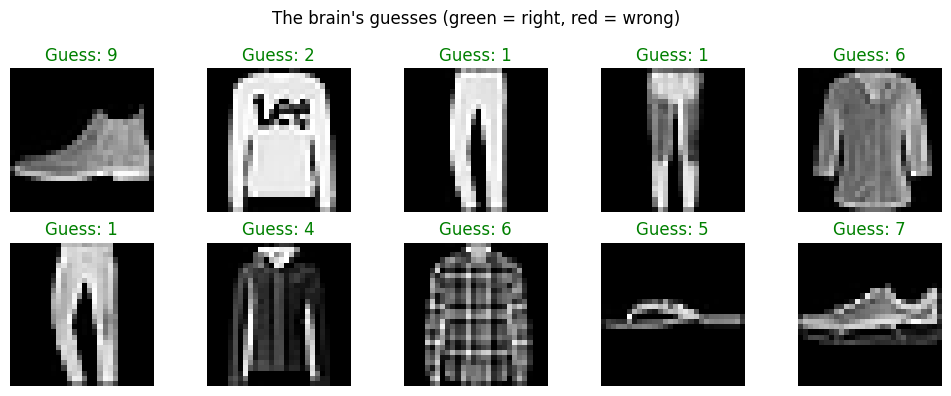

In [20]:
# نعرض 10 صور مع تخمين الشبكة (أخضر = صحيح، أحمر = خطأ)
images, answers = next(iter(test_loader))
scores = model(images)
_, predictions = scores.max(1)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i][0], cmap='gray')
    color = 'green' if predictions[i] == answers[i] else 'red'
    plt.title(f"Guess: {predictions[i].item()}", color=color)
    plt.axis('off')
plt.suptitle("The brain's guesses (green = right, red = wrong)")
plt.tight_layout()
plt.show()

## You did it!

You built and trained a real neural network that recognizes clothing. In one sentence:

> We showed a clueless "brain" thousands of labeled images, graded every guess, and let a coach
> nudge its knobs until it learned to recognize the clothes on its own.

### Try changing one thing and re-running:
1. **More practice:** `epochs = 3` → `epochs = 5`. Does accuracy go up?
2. **A bigger brain:** change `128` to `256` in `fc1`/`fc2`.
3. **Coaching speed:** change `lr=0.001` to `lr=0.01`.

Breaking things and fixing them is exactly how you learn. Have fun!

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h2 style="margin-top:0;"> لقد نجحت!</h2>
<p>لقد بنيت ودرّبت شبكة عصبية حقيقية تتعرّف على الملابس. في جملة واحدة:</p>
<blockquote style="border-right:4px solid #3b82c4; margin:0; padding:8px 16px; background:#eef4fb; border-radius:6px;">عرضنا على «دماغ» بلا خبرة آلاف الصور المصنّفة، وصحّحنا كل تخمين، وتركنا مدرّبًا يعدّل مقابضه حتى تعلّم التعرّف على الملابس بنفسه.</blockquote>
<h3 style="margin-bottom:6px;">جرّب تغيير شيء واحد وأعد التشغيل:</h3>
<ol style="padding-right:22px; margin:0;">
<li style="margin-bottom:6px;"><strong>تمرّن أكثر:</strong> <code>epochs = 5</code> ← <code>epochs = 3</code>. هل ترتفع الدقّة؟</li>
<li style="margin-bottom:6px;"><strong>دماغ أكبر:</strong> غيّر <code>128</code> إلى <code>256</code> في <code>fc1</code>/<code>fc2</code>.</li>
<li style="margin-bottom:0;"><strong>سرعة التدريب:</strong> غيّر <code>lr=0.001</code> إلى <code>lr=0.01</code>.</li>
</ol>
<p style="margin-top:12px; margin-bottom:0;">كسر الأشياء وإصلاحها هو بالضبط كيف تتعلّم. استمتع!</p>
</div>